In [67]:
import os, pandas as pd, numpy as np
from datetime import datetime
from pathlib import Path
import latency_evt_workflow as wf
import sys, importlib, inspect


sys.path.append('./')
import evt_triage as et

# Output directory
OUT_DIR = os.path.abspath(f"./latency_evt_reports_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_DIR


'/Users/soheila/Desktop/RealTime-Streaming-Pipeline/Analysis-Src/latency_evt_reports_20250925_203118'

In [68]:


# Make sure the version I gave you is imported first
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

# Optionally de-prioritize /Analysis-Src so it doesn't shadow
if "/Analysis-Src" in sys.path:
    sys.path.remove("/Analysis-Src")
    sys.path.append("/Analysis-Src")  # keep it, but after /mnt/data

import latency_evt_workflow as wf
importlib.reload(wf)  # ensure fresh load

print("Using module:", wf.__file__)
assert hasattr(wf, "set_label_overrides"), "This wf doesn't have set_label_overrides; path order is wrong."


Using module: /Users/soheila/Desktop/RealTime-Streaming-Pipeline/Analysis-Src/latency_evt_workflow.py


,label,full_gev_c,full_gev_loc,full_gev_scale,full_gev_type,full_KS_D,full_KS_p_asym,full_KS_p_boot,trunc_Fu,trunc_KS_D,trunc_KS_p_asym,trunc_KS_p_boot,gpd_c,gpd_scale,gpd_type,gpd_KS_D,gpd_KS_p_asym,gpd_KS_p_boot
0,POLL_TIMEOUT=20ms,-1.016461,0.021963,0.002630,Weibull (upper-bounded),0.333342,0.0,0.0,0.997099,0.339287,0.0,0.0,-0.181352,26.672458,bounded (xi<0),0.102909,1.016322e-20,0.0
1,POLL_TIMEOUT=3ms,-1.684077,0.006978,0.002228,Weibull (upper-bounded),0.394652,0.0,0.0,0.980592,0.402061,0.0,0.0,-0.137551,24.613208,bounded (xi<0),0.143768,2.400016e-44,0.0
2,POLL_TIMEOUT=5ms,-1.273055,0.004565,0.000937,Weibull (upper-bounded),0.537828,0.0,0.0,0.996537,0.535983,0.0,0.0,-0.610646,30.304204,bounded (xi<0),0.177027,3.367182e-04,0.0


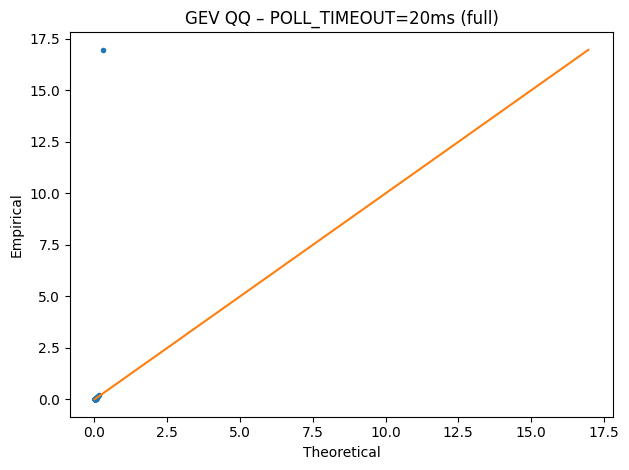

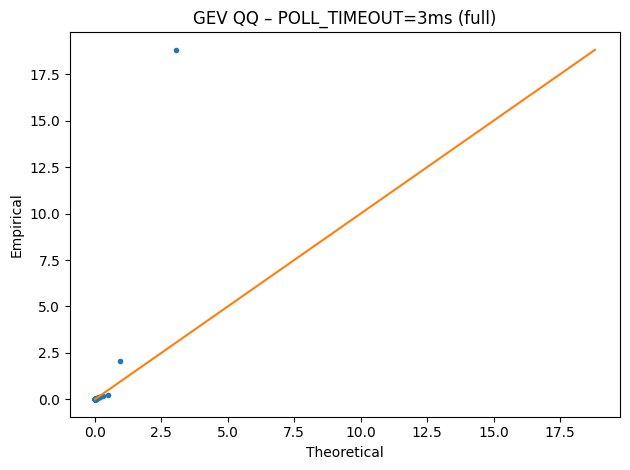

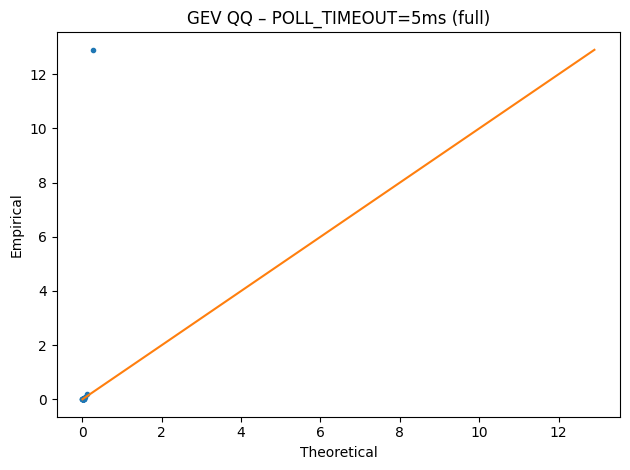

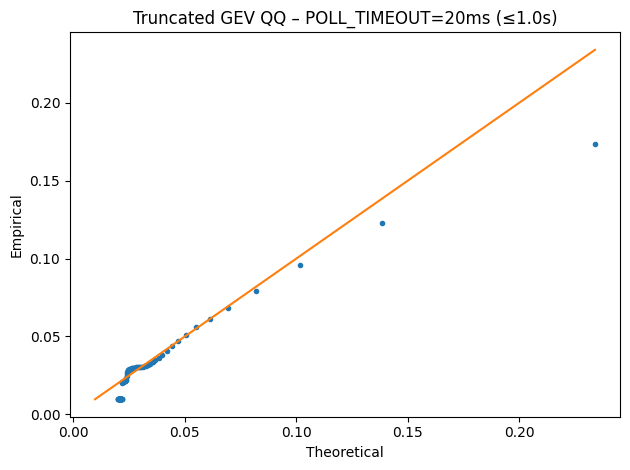

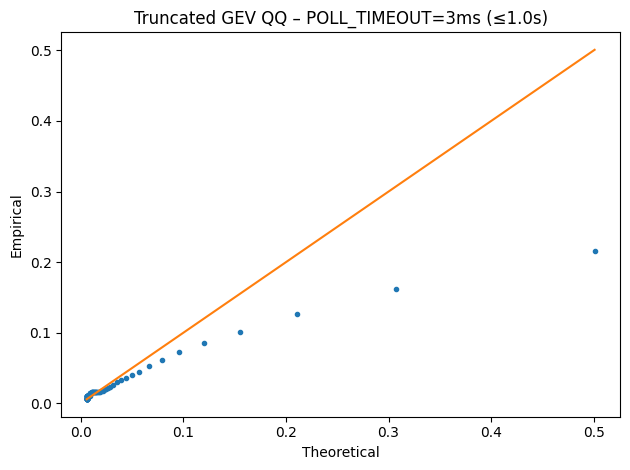

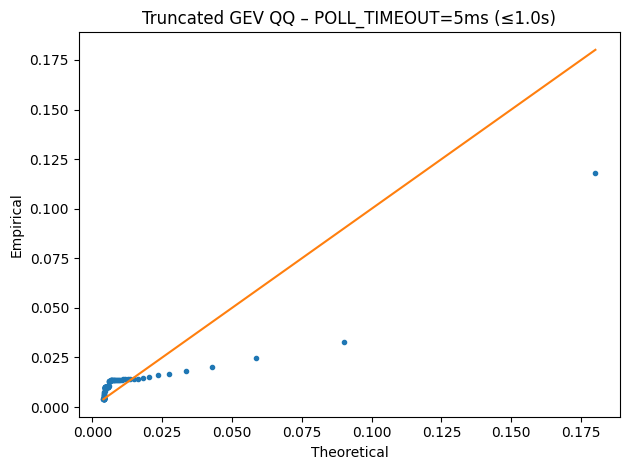

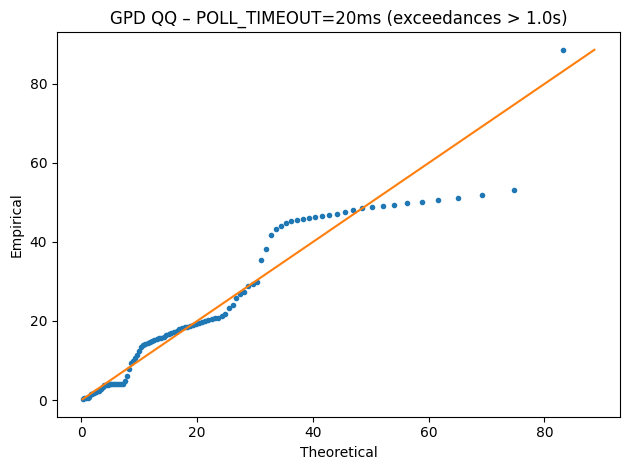

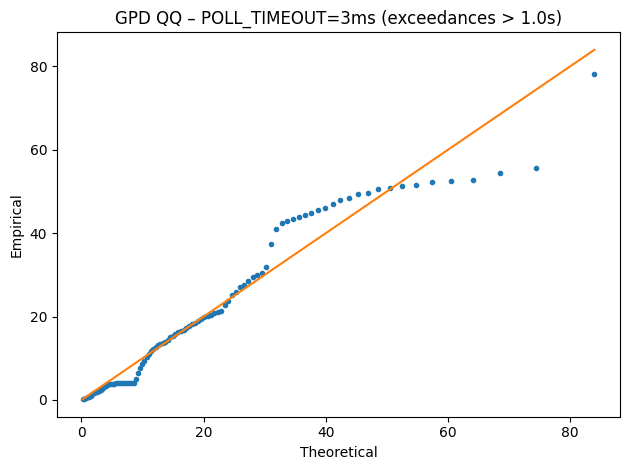

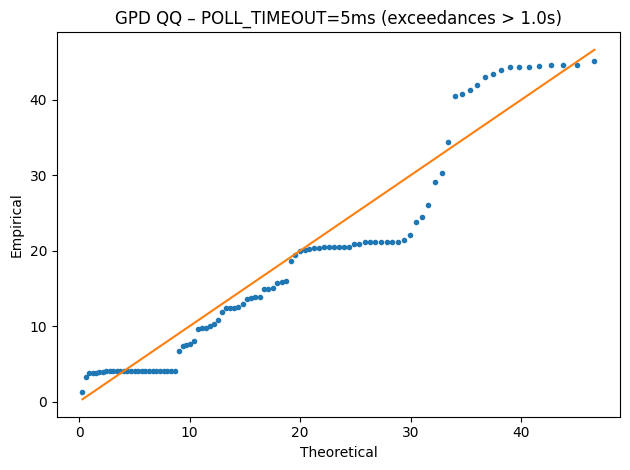

In [43]:
import sys, os, pandas as pd
sys.path.append('.')  

# or: sys.path.append('/mnt/data')  

# u in seconds B = bootstrap reps
#csv_path = et.run_all_three(experiments, OUT_DIR, u=1.0, B=100, show=False)
csv_path = et.run_all_three_fast(experiments, OUT_DIR, u=1.0, B=100, show=False)


# See compact results
pd.read_csv(csv_path)

In [69]:
import os, pandas as pd, numpy as np
from scipy import stats

# Assumptions:
# - Your existing `experiments` list came from wf.analyze_experiment(...)
# - Each experiment dict has e["label"] and e["dir"] (experiment directory),
#   and your block maxima live at: <dir>/block_maxima.csv with column "computed_at" (ISO) and "block_max_value" (seconds).

def _load_maxima_df(exp_dir):
    path = os.path.join(exp_dir, "block_maxima.csv")
    df = pd.read_csv(path)
    # strict column names the user gave:
    # file_name, computed_at, metric, scope, pod, block_max_value, rows_in_block, config_hash
    df["computed_at"] = pd.to_datetime(df["computed_at"], utc=True, errors="coerce")
    df = df.dropna(subset=["computed_at", "block_max_value"])
    return df

def trim_by_warmup_minutes(experiments, warmup_minutes=5, u=1.0):
    """
    Returns a *new* experiments list where maxima earlier than start+warmup are removed,
    and GEV/GPD parameters are *re-fitted* on the trimmed data.
    """
    new_exps = []
    for e in experiments:
        exp_dir = e.get("dir", None)
        if exp_dir is None:
            # if original 'dir' wasn't stored, skip
            print(f"[warn] missing 'dir' for {e['label']}, skipping trim")
            continue

        df = _load_maxima_df(exp_dir)
        t0 = df["computed_at"].min()
        cutoff = t0 + pd.Timedelta(minutes=warmup_minutes)
        df_trim = df[df["computed_at"] >= cutoff].copy()

        maxima = df_trim["block_max_value"].astype(float).to_numpy()
        maxima = maxima[np.isfinite(maxima)]

        if maxima.size < 10:
            print(f"[warn] {e['label']}: not enough points after trimming ({maxima.size}), skipping.")
            continue

        # Refit GEV on trimmed maxima
        c, loc, scale = stats.genextreme.fit(maxima)
        scale = max(scale, 1e-9)

        # Exceedances for GPD
        exc = maxima[maxima > u] - u
        gpd_params = None
        if exc.size >= 10:
            xi, l0, beta = stats.genpareto.fit(exc, floc=0.0)
            beta = max(beta, 1e-12)
            gpd_params = dict(c=xi, loc=0.0, scale=beta)

        new_exps.append({
            "label": e["label"] + f" (trim {warmup_minutes}m)",
            "dir": exp_dir,
            "maxima": maxima,
            "gev_params": dict(c=c, loc=loc, scale=scale),
            "threshold": float(u),
            "exceedances": exc if exc.size else np.array([], dtype=float),
            "gpd_params": gpd_params
        })
    return new_exps


In [60]:
import os, time
import evt_triage as et  # the helper you’re already using

WARMUP_MIN = 1       
U_SECONDS  = 1.0        # tail threshold for GPD and truncated GEV

# Make a sibling OUT_DIR to compare before vs after
OUT_DIR = os.path.abspath(f"./latency_evt_reports_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}")
OUT_DIR_TRIM = os.path.join(OUT_DIR, f"trim_{WARMUP_MIN}m")
os.makedirs(OUT_DIR_TRIM, exist_ok=True)

# Build trimmed experiments and re-run the 3 analyses
trimmed_experiments = trim_by_warmup_minutes(experiments, warmup_minutes=WARMUP_MIN, u=U_SECONDS)
csv_trim = et.run_all_three(trimmed_experiments, OUT_DIR_TRIM, u=U_SECONDS, B=200, show=False)

import pandas as pd
print("Original summary:", os.path.join(OUT_DIR,       "evt_triage_summary.csv"))
print("Trimmed  summary:", os.path.join(OUT_DIR_TRIM, "evt_triage_summary.csv"))
pd.read_csv(csv_trim)


[warn] POLL_TIMEOUT=20ms: not enough points after trimming (0), skipping.
[warn] POLL_TIMEOUT=3ms: not enough points after trimming (0), skipping.
[warn] POLL_TIMEOUT=5ms: not enough points after trimming (0), skipping.


TypeError: run_all_three_safe() missing 1 required positional argument: 'jitter'

In [70]:
import types, pandas as pd, os
import evt_triage as et

def run_all_three_safe(experiments, out_dir, u=1.0, B=200, show=False, jitter=1e-6):
    os.makedirs(out_dir, exist_ok=True)
    df1 = et.analyze_full_gev(experiments, out_dir, B=B, show=show, jitter=jitter)
    df2 = et.analyze_truncated_gev(experiments, out_dir, u=u, B=B, show=show, jitter=jitter)
    df3 = et.analyze_gpd_tail(experiments, out_dir, u=u, B=B, show=show, jitter=jitter)

    parts = []

    if isinstance(df1, pd.DataFrame) and not df1.empty:
        cols = ["label","gev_c","gev_loc","gev_scale","gev_type","KS_D","KS_p_asym","KS_p_boot"]
        have = [c for c in cols if c in df1.columns]
        if have:
            df1a = df1[have].copy()
            rename = {c: f"full_{c}" for c in have if c != "label"}
            df1a.rename(columns=rename, inplace=True)
            parts.append(df1a)
    else:
        print("[warn] full GEV produced no rows — likely too few points after trimming.")

    if isinstance(df2, pd.DataFrame) and not df2.empty:
        cols = ["label","F_u","KS_D","KS_p_asym","KS_p_boot"]
        have = [c for c in cols if c in df2.columns]
        if have:
            df2a = df2[have].copy()
            df2a.rename(columns={
                "F_u":"trunc_Fu",
                "KS_D":"trunc_KS_D",
                "KS_p_asym":"trunc_KS_p_asym",
                "KS_p_boot":"trunc_KS_p_boot"
            }, inplace=True)
            parts.append(df2a)
    else:
        print("[warn] truncated GEV produced no rows.")

    if isinstance(df3, pd.DataFrame) and not df3.empty:
        cols = ["label","gpd_c","gpd_scale","gpd_type","KS_D","KS_p_asym","KS_p_boot"]
        have = [c for c in cols if c in df3.columns]
        if have:
            df3a = df3[have].copy()
            df3a.rename(columns={
                "KS_D":"gpd_KS_D",
                "KS_p_asym":"gpd_KS_p_asym",
                "KS_p_boot":"gpd_KS_p_boot"
            }, inplace=True)
            parts.append(df3a)
    else:
        print("[warn] GPD tail produced no rows — maybe not enough exceedances after trimming.")

    if parts:
        out = parts[0]
        for p in parts[1:]:
            out = out.merge(p, on="label", how="outer")
    else:
        out = pd.DataFrame(columns=[
            "label","full_gev_c","full_gev_loc","full_gev_scale","full_gev_type",
            "full_KS_D","full_KS_p_asym","full_KS_p_boot",
            "trunc_Fu","trunc_KS_D","trunc_KS_p_asym","trunc_KS_p_boot",
            "gpd_c","gpd_scale","gpd_type","gpd_KS_D","gpd_KS_p_asym","gpd_KS_p_boot"
        ])

    out_csv = os.path.join(out_dir, "evt_triage_summary.csv")
    out.to_csv(out_csv, index=False)
    return out_csv

# Monkey-patch the module to use the safe version
et.run_all_three = types.FunctionType(run_all_three_safe.__code__, globals(), "run_all_three")
print("Patched evt_triage.run_all_three -> run_all_three_safe")


Patched evt_triage.run_all_three -> run_all_three_safe


In [71]:
import os, pandas as pd, numpy as np

def peek_block_maxima(exp_dir, n=5):
    path = os.path.join(exp_dir, "block_maxima.csv")
    df = pd.read_csv(path)
    print(f"\n[{exp_dir}] rows={len(df)}")
    print("columns:", list(df.columns))
    print(df.head(n))
    return df

def parse_computed_at(series):
    s = series.copy()

    # Try ISO first
    ts_iso = pd.to_datetime(s, utc=True, errors="coerce")

    # If too many NaT, try UNIX seconds
    nat_ratio = ts_iso.isna().mean()
    if nat_ratio > 0.5:
        try:
            ts_sec = pd.to_datetime(s.astype(float), unit="s", utc=True, errors="coerce")
        except Exception:
            ts_sec = pd.Series(pd.NaT, index=s.index)
        # If still bad, try UNIX milliseconds
        if ts_sec.isna().mean() > 0.5:
            try:
                ts_ms = pd.to_datetime(s.astype(float), unit="ms", utc=True, errors="coerce")
            except Exception:
                ts_ms = pd.Series(pd.NaT, index=s.index)
            ts = ts_ms
        else:
            ts = ts_sec
    else:
        ts = ts_iso

    return ts

def diagnose_timestamps(exp_dir):
    path = os.path.join(exp_dir, "block_maxima.csv")
    df = pd.read_csv(path)
    assert "computed_at" in df.columns, "block_maxima.csv missing 'computed_at'"
    ts = parse_computed_at(df["computed_at"])
    ok = ts.notna().sum()
    print(f"\n[{exp_dir}] parsed timestamps OK={ok}/{len(df)}  NaT={len(df)-ok}")
    if ok:
        print("min:", ts.min(), "max:", ts.max(), "span(s):", (ts.max()-ts.min()).total_seconds())
        # Show a few raw -> parsed
        sample = pd.DataFrame({"raw": df["computed_at"].head(5), "parsed": ts.head(5)})
        print(sample)
    return ts


In [72]:
THRESHOLD_S = 1.0

EXPERIMENT_DIRS = [
    "../results/20250922_121352/merge/merge-sts-0_merge-metrics/2025-09-22/", # 20 ms
    "../results/20250922_065826/merge/merge-sts-0_merge-metrics/2025-09-22/", # 3 ms
    "../results/20250922_021233/merge/merge-sts-0_merge-metrics/2025-09-22/", # 5 ms
    "../results/20250922_163656/merge/merge-sts-0_merge-metrics/2025-09-22/", # 15 ms
    "../results/20250923_132141/merge/merge-sts-0_merge-metrics/2025-09-22/", # 10 ms
    
]


wf.set_label_overrides({
    EXPERIMENT_DIRS[0]: "POLL_TIMEOUT=20ms",
    EXPERIMENT_DIRS[1]: "POLL_TIMEOUT=3ms",
    EXPERIMENT_DIRS[2]: "POLL_TIMEOUT=5ms",
    EXPERIMENT_DIRS[3]: "POLL_TIMEOUT=15ms",
    EXPERIMENT_DIRS[4]: "POLL_TIMEOUT=10ms",
})

experiments = []
for d in EXPERIMENT_DIRS:
    e = wf.analyze_experiment(d, threshold_s=THRESHOLD_S)
    e["dir"] = d                 # <-- add this line
    experiments.append(e)

len(experiments)

5

In [65]:
WARMUP_MIN = 0        # try 1 first
U_SECONDS  = 1.0

# Optionally, also give a row-fraction fallback if timestamps are bad:
trimmed_experiments = trim_by_warmup(experiments, warmup_minutes=WARMUP_MIN, warmup_fraction=0.02, u=U_SECONDS)
#trimmed_experiments = trim_by_warmup(experiments, warmup_minutes=WARMUP_MIN, u=U_SECONDS)

# Re-run analyses (lower B & show=False for speed at first)
csv_trim = et.run_all_three(trimmed_experiments, os.path.join(OUT_DIR, f"trim_{WARMUP_MIN}m"), u=U_SECONDS, B=100, show=False, jitter=1e-6)
import pandas as pd
pd.read_csv(csv_trim)


[ok] POLL_TIMEOUT=20ms: kept 122940/125448 after trim; GEV c=-1.658, loc=0.012, scale=0.005, exceed=2174
[ok] POLL_TIMEOUT=3ms: kept 111803/114084 after trim; GEV c=-1.109, loc=0.009, scale=0.005, exceed=2357
[ok] POLL_TIMEOUT=5ms: kept 8074/8238 after trim; GEV c=-0.670, loc=0.008, scale=0.004, exceed=110
[ok] POLL_TIMEOUT=15ms: kept 67591/68970 after trim; GEV c=-1.601, loc=0.012, scale=0.005, exceed=1332
[ok] POLL_TIMEOUT=10ms: kept 308901/315205 after trim; GEV c=-1.353, loc=0.012, scale=0.004, exceed=6586


,label,full_gev_c,full_gev_loc,full_gev_scale,full_gev_type,full_KS_D,full_KS_p_asym,full_KS_p_boot,trunc_Fu,trunc_KS_D,trunc_KS_p_asym,trunc_KS_p_boot,gpd_c,gpd_scale,gpd_type,gpd_KS_D,gpd_KS_p_asym,gpd_KS_p_boot
0,POLL_TIMEOUT=20ms (trim 0m),-1.658439,0.012256,0.005162,Weibull (upper-bounded),0.297417,0.0,0.00,0.969514,0.311282,0.0,0.0,-0.186953,27.047625,bounded (xi<0),0.096384,4.968106e-18,0.0
1,POLL_TIMEOUT=3ms (trim 0m),-1.108749,0.009377,0.004882,Weibull (upper-bounded),0.187373,0.0,0.02,0.992498,0.186019,0.0,0.0,-0.147112,25.174186,bounded (xi<0),0.136019,1.702531e-38,0.0
2,POLL_TIMEOUT=5ms (trim 0m),-0.669506,0.007500,0.004100,Weibull (upper-bounded),0.242095,0.0,0.00,0.999504,0.238454,0.0,0.0,-1.082917,49.197361,bounded (xi<0),0.283309,2.639222e-08,0.0
3,POLL_TIMEOUT=15ms (trim 0m),-1.601386,0.012002,0.004588,Weibull (upper-bounded),0.213927,0.0,0.00,0.974358,0.221649,0.0,0.0,-0.218921,21.577933,bounded (xi<0),0.192576,9.648810e-44,0.0
4,POLL_TIMEOUT=10ms (trim 0m),-1.353069,0.011551,0.003541,Weibull (upper-bounded),0.190010,0.0,0.00,0.987647,0.195114,0.0,0.0,-0.009581,18.189816,exponential-like (xi≈0),0.146406,1.129821e-123,0.0


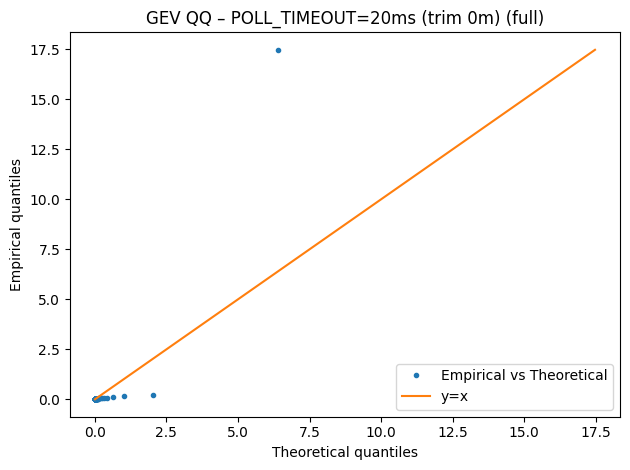

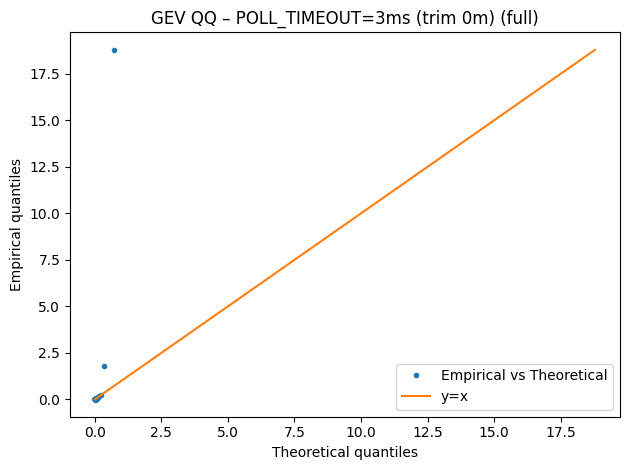

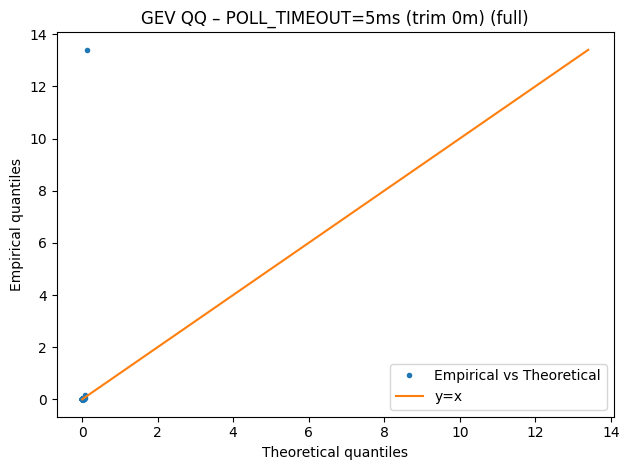

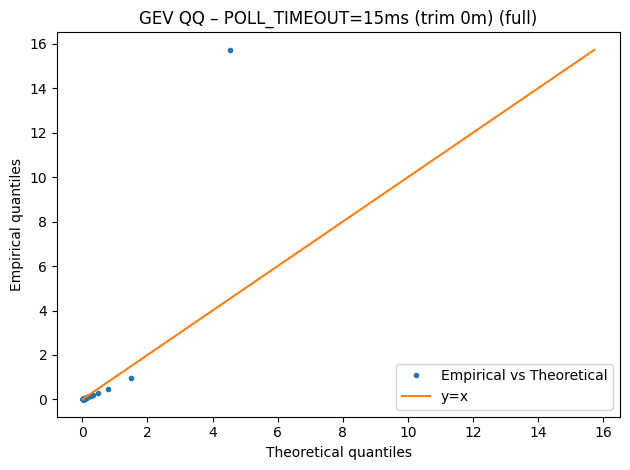

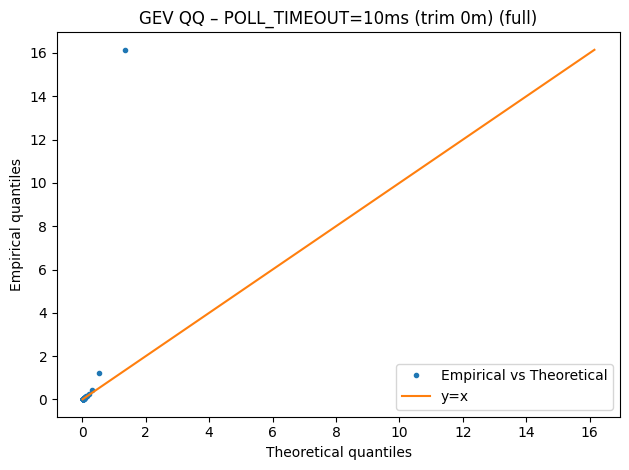

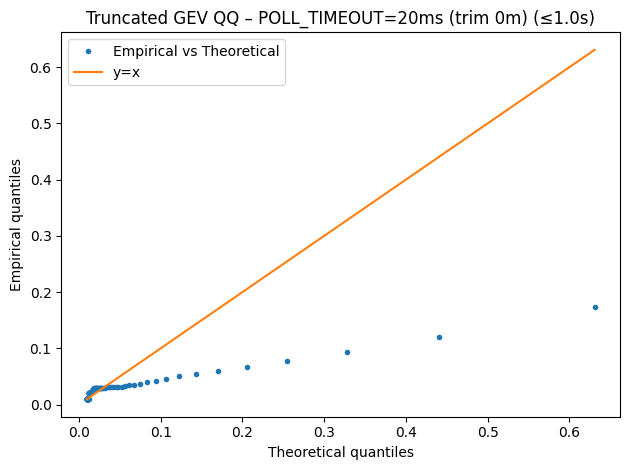

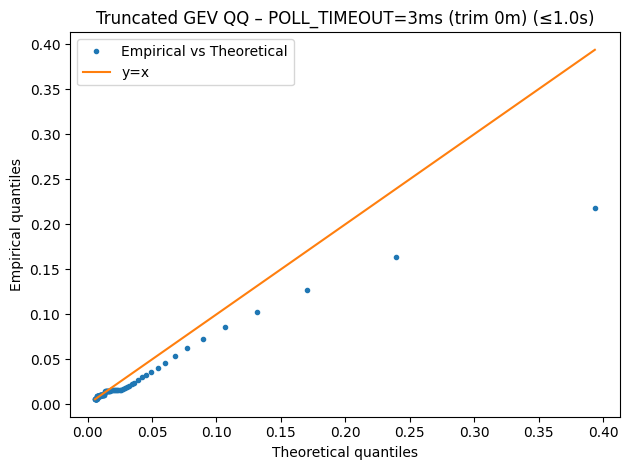

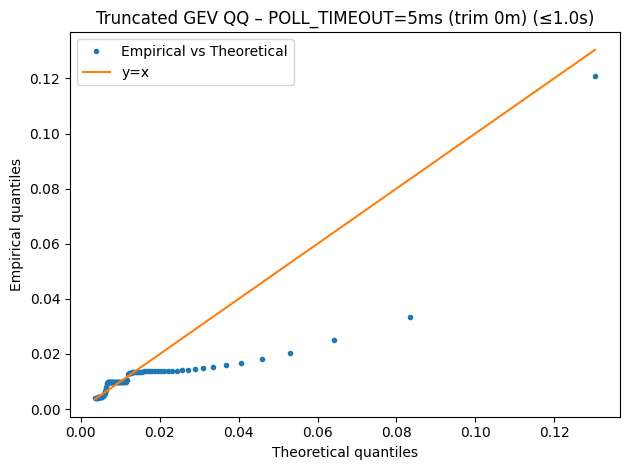

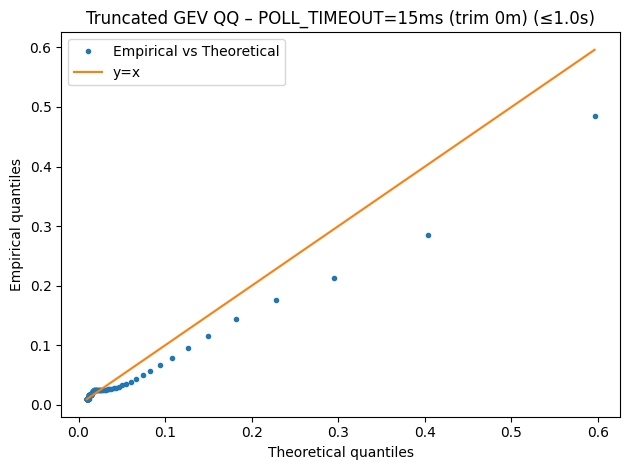

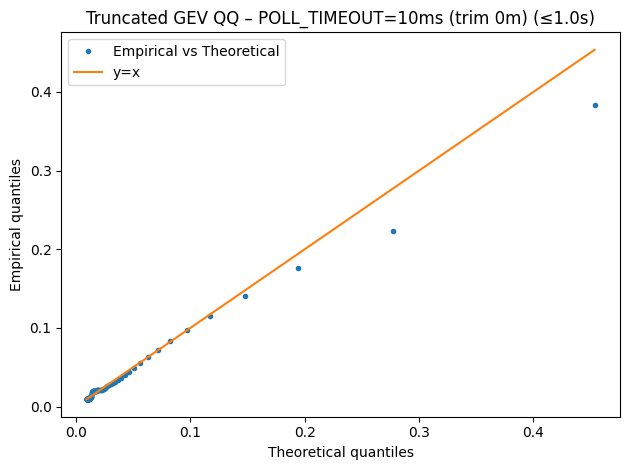

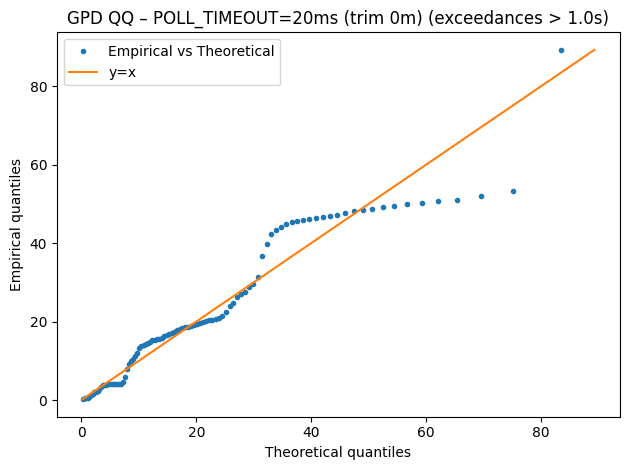

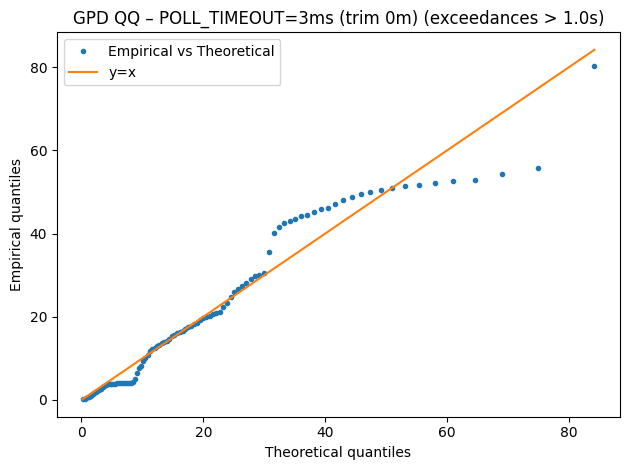

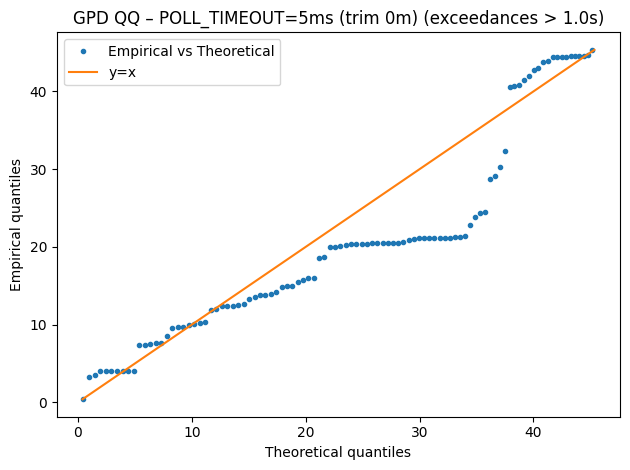

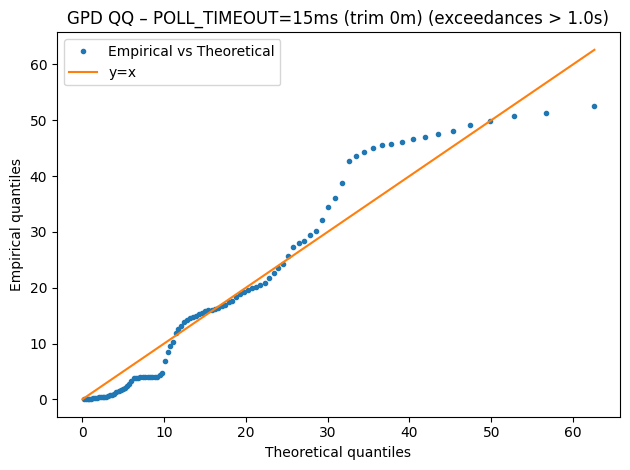

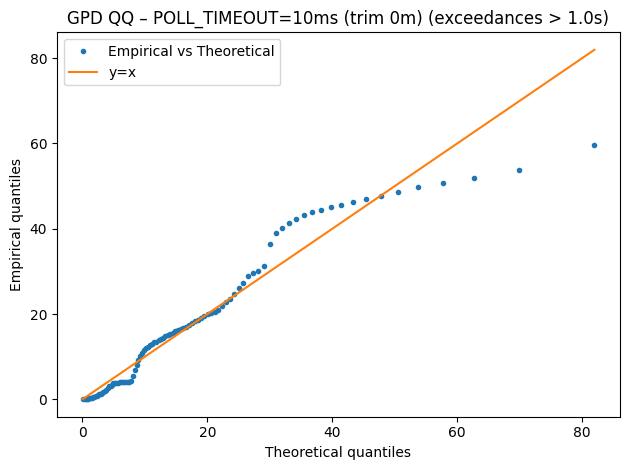

=== FULL GEV on all maxima ===
                         label     gev_c                 gev_type      KS_D  \
0  POLL_TIMEOUT=20ms (trim 0m) -1.658439  Weibull (upper-bounded)  0.297417   
1   POLL_TIMEOUT=3ms (trim 0m) -1.108749  Weibull (upper-bounded)  0.187373   
2   POLL_TIMEOUT=5ms (trim 0m) -0.669506  Weibull (upper-bounded)  0.242095   
3  POLL_TIMEOUT=15ms (trim 0m) -1.601386  Weibull (upper-bounded)  0.213927   
4  POLL_TIMEOUT=10ms (trim 0m) -1.353069  Weibull (upper-bounded)  0.190010   

   KS_p_boot verdict  
0      0.000    poor  
1      0.005    poor  
2      0.000    poor  
3      0.000    poor  
4      0.000    poor  

=== GPD on exceedances (>1s) ===
                         label     gpd_c                 gpd_type      KS_D  \
0  POLL_TIMEOUT=20ms (trim 0m) -0.186953           bounded (xi<0)  0.096384   
1   POLL_TIMEOUT=3ms (trim 0m) -0.147112           bounded (xi<0)  0.136019   
2   POLL_TIMEOUT=5ms (trim 0m) -1.082920           bounded (xi<0)  0.283310   
3  POL

In [66]:
import os, pandas as pd, numpy as np
import evt_triage as et

# 1) Full GEV diagnostics (fits + QQ + KS with bootstrap)
full_df = et.analyze_full_gev(trimmed_experiments, OUT_DIR_TRIM, B=200, show=True, jitter=1e-6)

# 2) Also check tails (GPD) & body (truncated GEV) if you want:
trunc_df = et.analyze_truncated_gev(trimmed_experiments, OUT_DIR_TRIM, u=1.0, B=200, show=True, jitter=1e-6)
gpd_df   = et.analyze_gpd_tail(trimmed_experiments, OUT_DIR_TRIM, u=1.0, B=200, show=True, jitter=1e-6)

# 3) Print a compact verdict for GEV + tail
def say_fit(p_boot):
    if pd.isna(p_boot): return "insufficient data"
    if p_boot >= 0.10:  return "OK"
    if p_boot >= 0.03:  return "borderline"
    return "poor"

print("=== FULL GEV on all maxima ===")
print(full_df[["label","gev_c","gev_type","KS_D","KS_p_boot"]].assign(verdict=full_df["KS_p_boot"].map(say_fit)))

print("\n=== GPD on exceedances (>1s) ===")
subset = gpd_df[["label","gpd_c","gpd_type","KS_D","KS_p_boot"]] if not gpd_df.empty else pd.DataFrame()
print(subset.assign(verdict=subset["KS_p_boot"].map(say_fit)) if not subset.empty else "no exceedances or skipped")

# (Optional) practical high quantiles from the fitted full GEV
from scipy import stats
rows=[]
for e in trimmed_experiments:
    p = e["gev_params"]
    q999  = stats.genextreme.ppf(0.999,  c=p["c"], loc=p["loc"], scale=p["scale"])
    q9999 = stats.genextreme.ppf(0.9999, c=p["c"], loc=p["loc"], scale=p["scale"])
    rows.append({"label":e["label"], "q(0.999)":q999, "q(0.9999)":q9999})
print("\n=== Practical upper quantiles from full GEV ===")
print(pd.DataFrame(rows))
